In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils.torchutils import BoxUniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

torch_device = "cpu"

In [2]:
prior = BoxUniform(
    low=torch.tensor([0.0, 1.0, 0.0], device=torch_device),
    high=torch.tensor([0.2, 2000.0, 0.2], device=torch_device), 
    device=torch_device
)

In [3]:
x_o_1 = np.loadtxt('../data/ClonalOrigin/x_o_1.csv', delimiter=",")
x_o_1 = torch.tensor(x_o_1, device=torch_device)
x_o_1 = x_o_1.to(torch.float32)
x_o_1 = x_o_1.flatten()
x_o_1_numpy = x_o_1.cpu().numpy()
x_o_1

tensor([0.2086, 0.1273, 0.0928, 0.0675, 0.1225, 0.1625, 0.0314, 0.3184])

In [4]:
theta_1 = np.loadtxt('../data/ClonalOrigin/theta_1.csv', delimiter=",")
theta_1 = torch.tensor(theta_1, device=torch_device)
theta_1 = theta_1.to(torch.float32)
theta_1_numpy = theta_1.cpu().numpy()
theta_1

tensor([[5.1383e-03, 1.2563e+02, 4.4089e-02],
        [1.2599e-01, 1.6953e+03, 1.1464e-01],
        [4.4225e-02, 8.0324e+02, 1.1582e-01],
        ...,
        [3.5024e-02, 5.1136e+02, 4.8810e-02],
        [1.5444e-01, 2.3510e+02, 1.7987e-01],
        [1.7408e-01, 1.2276e+03, 1.8106e-02]])

In [5]:
x_1 = np.loadtxt('../data/ClonalOrigin/x_1.csv', delimiter=",")
x_1 = torch.tensor(x_1, device=torch_device)
x_1 = x_1.to(torch.float32)
x_1_numpy = x_1.cpu().numpy()
x_1

tensor([[0.2647, 0.2261, 0.2023,  ..., 0.0560, 0.0198, 0.2081],
        [0.0933, 0.0736, 0.0614,  ..., 0.2365, 0.3087, 0.7487],
        [0.1465, 0.1019, 0.0632,  ..., 0.2540, 0.1433, 0.5266],
        ...,
        [0.1736, 0.1037, 0.0653,  ..., 0.2020, 0.0493, 0.3336],
        [0.1044, 0.0712, 0.0603,  ..., 0.3195, 0.2020, 0.6599],
        [0.0929, 0.0710, 0.0580,  ..., 0.0805, 0.0589, 0.5005]])

In [6]:
x_o_1.shape, theta_1.shape, x_1.shape

(torch.Size([8]), torch.Size([2000, 3]), torch.Size([2000, 8]))

In [7]:
x_o_2 = np.loadtxt('../data/ClonalOrigin/x_o_2.csv', delimiter=",")
x_o_2 = torch.tensor(x_o_2, device=torch_device)
x_o_2 = x_o_2.to(torch.float32)
x_o_2 = x_o_2.flatten()
x_o_2_numpy = x_o_2.cpu().numpy()
x_o_2

tensor([0.2086, 0.1273, 0.0928, 0.0675, 0.1225, 0.1625, 0.0314, 0.3184])

In [8]:
theta_2 = np.loadtxt('../data/ClonalOrigin/theta_2.csv', delimiter=",")
theta_2 = torch.tensor(theta_2, device=torch_device)
theta_2 = theta_2.to(torch.float32)
theta_2_numpy = theta_2.cpu().numpy()
theta_2

tensor([[1.3740e-01, 6.4424e+02, 7.4060e-02],
        [1.0827e-01, 1.5527e+03, 2.9214e-02],
        [1.2972e-01, 1.7090e+03, 1.9280e-01],
        ...,
        [2.8957e-02, 1.2545e+03, 1.5810e-01],
        [6.4610e-02, 2.0036e+02, 1.3191e-02],
        [1.8472e-01, 1.3463e+03, 1.8316e-01]])

In [9]:
x_2 = np.loadtxt('../data/ClonalOrigin/x_2.csv', delimiter=",")
x_2 = torch.tensor(x_2, device=torch_device)
x_2 = x_2.to(torch.float32)
x_2_numpy = x_2.cpu().numpy()
x_2

tensor([[0.1066, 0.0734, 0.0587,  ..., 0.2020, 0.1521, 0.5556],
        [0.1098, 0.0788, 0.0576,  ..., 0.1030, 0.0861, 0.5101],
        [0.1019, 0.0795, 0.0636,  ..., 0.4160, 0.4283, 0.8908],
        ...,
        [0.1524, 0.1132, 0.0671,  ..., 0.2905, 0.1873, 0.6180],
        [0.1403, 0.0843, 0.0681,  ..., 0.1645, 0.0125, 0.2759],
        [0.0936, 0.0793, 0.0645,  ..., 0.3695, 0.4315, 0.8920]])

In [10]:
x_o_2.shape, theta_2.shape, x_2.shape

(torch.Size([8]), torch.Size([2000, 3]), torch.Size([2000, 8]))

In [11]:
x_o_3 = np.loadtxt('../data/ClonalOrigin/x_o_3.csv', delimiter=",")
x_o_3 = torch.tensor(x_o_3, device=torch_device)
x_o_3 = x_o_3.to(torch.float32)
x_o_3 = x_o_3.flatten()
x_o_3_numpy = x_o_3.cpu().numpy()
x_o_3

tensor([0.2086, 0.1273, 0.0928, 0.0675, 0.1225, 0.1625, 0.0314, 0.3184])

In [12]:
theta_3 = np.loadtxt('../data/ClonalOrigin/theta_3.csv', delimiter=",")
theta_3 = torch.tensor(theta_3, device=torch_device)
theta_3 = theta_3.to(torch.float32)
theta_3_numpy = theta_3.cpu().numpy()
theta_3

tensor([[1.4065e-01, 1.7577e+03, 9.3623e-02],
        [9.2912e-02, 1.1438e+03, 7.2642e-02],
        [1.9489e-01, 1.2559e+03, 2.9428e-03],
        ...,
        [1.6554e-01, 4.7784e+02, 1.7021e-01],
        [3.7269e-02, 1.7325e+03, 1.0134e-01],
        [1.1680e-01, 1.5038e+03, 1.6605e-02]])

In [13]:
x_3 = np.loadtxt('../data/ClonalOrigin/x_3.csv', delimiter=",")
x_3 = torch.tensor(x_3, device=torch_device)
x_3 = x_3.to(torch.float32)
x_3_numpy = x_3.cpu().numpy()
x_3

tensor([[0.0979, 0.0793, 0.0590,  ..., 0.2070, 0.2706, 0.7070],
        [0.1029, 0.0881, 0.0631,  ..., 0.1870, 0.1638, 0.5929],
        [0.0867, 0.0746, 0.0514,  ..., 0.0450, 0.0092, 0.4582],
        ...,
        [0.0990, 0.0732, 0.0667,  ..., 0.3360, 0.2808, 0.7517],
        [0.1369, 0.1062, 0.0626,  ..., 0.2290, 0.1744, 0.5788],
        [0.1007, 0.0725, 0.0562,  ..., 0.0735, 0.0532, 0.4449]])

In [14]:
x_o_3.shape, theta_3.shape, x_3.shape

(torch.Size([8]), torch.Size([2000, 3]), torch.Size([2000, 8]))

In [15]:
x_o_4 = np.loadtxt('../data/ClonalOrigin/x_o_4.csv', delimiter=",")
x_o_4 = torch.tensor(x_o_4, device=torch_device)
x_o_4 = x_o_4.to(torch.float32)
x_o_4 = x_o_4.flatten()
x_o_4_numpy = x_o_4.cpu().numpy()
x_o_4

tensor([0.2086, 0.1273, 0.0928, 0.0675, 0.1225, 0.1625, 0.0314, 0.3184])

In [16]:
theta_4 = np.loadtxt('../data/ClonalOrigin/theta_4.csv', delimiter=",")
theta_4 = torch.tensor(theta_4, device=torch_device)
theta_4 = theta_4.to(torch.float32)
theta_4_numpy = theta_4.cpu().numpy()
theta_4

tensor([[1.7518e-01, 1.5249e+03, 5.8425e-02],
        [1.9307e-01, 2.1386e+02, 1.7826e-02],
        [1.8033e-01, 1.3857e+02, 1.2493e-01],
        ...,
        [6.7089e-02, 6.5156e+02, 1.8955e-01],
        [1.0957e-01, 1.9149e+03, 8.1356e-02],
        [1.9927e-01, 9.3030e+02, 2.8743e-02]])

In [17]:
x_4 = np.loadtxt('../data/ClonalOrigin/x_4.csv', delimiter=",")
x_4 = torch.tensor(x_4, device=torch_device)
x_4 = x_4.to(torch.float32)
x_4_numpy = x_4.cpu().numpy()
x_4

tensor([[0.0879, 0.0727, 0.0611,  ..., 0.1360, 0.1863, 0.6195],
        [0.0964, 0.0675, 0.0573,  ..., 0.1625, 0.0291, 0.3836],
        [0.0977, 0.0712, 0.0639,  ..., 0.2520, 0.1284, 0.5186],
        ...,
        [0.1252, 0.0925, 0.0622,  ..., 0.3375, 0.2402, 0.6773],
        [0.0962, 0.0867, 0.0629,  ..., 0.1810, 0.2382, 0.6608],
        [0.0906, 0.0717, 0.0589,  ..., 0.0980, 0.0915, 0.5254]])

In [18]:
x_o_4.shape, theta_4.shape, x_4.shape

(torch.Size([8]), torch.Size([2000, 3]), torch.Size([2000, 8]))

In [19]:
x_o_5 = np.loadtxt('../data/ClonalOrigin/x_o_5.csv', delimiter=",")
x_o_5 = torch.tensor(x_o_5, device=torch_device)
x_o_5 = x_o_5.to(torch.float32)
x_o_5 = x_o_5.flatten()
x_o_5_numpy = x_o_5.cpu().numpy()
x_o_5

tensor([0.2086, 0.1273, 0.0928, 0.0675, 0.1225, 0.1625, 0.0314, 0.3184])

In [20]:
theta_5 = np.loadtxt('../data/ClonalOrigin/theta_5.csv', delimiter=",")
theta_5 = torch.tensor(theta_5, device=torch_device)
theta_5 = theta_5.to(torch.float32)
theta_5_numpy = theta_5.cpu().numpy()
theta_5

tensor([[7.4138e-02, 1.5730e+03, 1.6489e-01],
        [4.7618e-02, 1.3741e+03, 1.4316e-02],
        [4.7581e-02, 1.1512e+02, 1.5568e-01],
        ...,
        [5.2704e-02, 1.2234e+03, 3.8654e-02],
        [1.3218e-01, 9.9647e+02, 1.8710e-01],
        [1.2915e-01, 1.7511e+03, 3.6169e-02]])

In [21]:
x_5 = np.loadtxt('../data/ClonalOrigin/x_5.csv', delimiter=",")
x_5 = torch.tensor(x_5, device=torch_device)
x_5 = x_5.to(torch.float32)
x_5_numpy = x_5.cpu().numpy()
x_5

tensor([[0.1115, 0.0893, 0.0648,  ..., 0.3225, 0.3254, 0.7669],
        [0.1309, 0.1083, 0.0561,  ..., 0.1160, 0.0309, 0.3702],
        [0.1460, 0.1026, 0.0855,  ..., 0.1940, 0.0818, 0.4221],
        ...,
        [0.1430, 0.0917, 0.0587,  ..., 0.1585, 0.0771, 0.3981],
        [0.1015, 0.0800, 0.0622,  ..., 0.3820, 0.3678, 0.8445],
        [0.0864, 0.0754, 0.0610,  ..., 0.0915, 0.1188, 0.5144]])

In [22]:
x_o_5.shape, theta_5.shape, x_5.shape

(torch.Size([8]), torch.Size([2000, 3]), torch.Size([2000, 8]))

In [24]:
print(x_o_1 == x_o_2)
print(x_o_1 == x_o_3)
print(x_o_1 == x_o_4)
print(x_o_1 == x_o_5)

tensor([True, True, True, True, True, True, True, True])
tensor([True, True, True, True, True, True, True, True])
tensor([True, True, True, True, True, True, True, True])
tensor([True, True, True, True, True, True, True, True])


In [25]:
theta_list = [theta_1, theta_2, theta_3, theta_4, theta_5]
theta = torch.cat(theta_list, dim=0)
theta.shape

torch.Size([10000, 3])

In [27]:
x_list = [x_1, x_2, x_3, x_4, x_5]
x = torch.cat(x_list, dim=0)
x.shape

torch.Size([10000, 8])

In [28]:
theta_sbc = np.loadtxt('../data/ClonalOrigin/theta_sbc.csv', delimiter=",")
theta_sbc = torch.tensor(theta_sbc, device=torch_device)
theta_sbc = theta_sbc.to(torch.float32)
theta_sbc_numpy = theta_sbc.cpu().numpy()
theta_sbc

tensor([[2.2333e-02, 1.6319e+03, 5.2512e-02],
        [9.6776e-02, 1.3533e+03, 1.5078e-01],
        [5.2538e-02, 8.6636e+01, 4.1606e-02],
        ...,
        [1.2851e-01, 3.2811e+02, 7.5176e-02],
        [1.4910e-01, 1.3152e+03, 1.3920e-01],
        [1.0730e-01, 1.2815e+03, 1.5275e-01]])

In [29]:
x_sbc = np.loadtxt('../data/ClonalOrigin/x_sbc.csv', delimiter=",")
x_sbc = torch.tensor(x_sbc, device=torch_device)
x_sbc = x_sbc.to(torch.float32)
x_sbc_numpy = x_sbc.cpu().numpy()
x_sbc

tensor([[0.1626, 0.1194, 0.0677,  ..., 0.1760, 0.0753, 0.3855],
        [0.1106, 0.0798, 0.0626,  ..., 0.3305, 0.3208, 0.7726],
        [0.1498, 0.1056, 0.0886,  ..., 0.1570, 0.0232, 0.2963],
        ...,
        [0.1099, 0.0747, 0.0649,  ..., 0.2095, 0.1107, 0.4651],
        [0.0941, 0.0789, 0.0621,  ..., 0.3045, 0.3399, 0.7960],
        [0.1088, 0.0768, 0.0601,  ..., 0.3135, 0.3258, 0.7854]])

In [30]:
theta_sbc.shape, x_sbc.shape

(torch.Size([500, 3]), torch.Size([500, 8]))

In [31]:
x_o = x_o_1

In [32]:
x_o.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32)

In [33]:
theta_sbc.dtype, x_sbc.dtype

(torch.float32, torch.float32)

In [34]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [35]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator).set_default_x(x_o)

 Neural network successfully converged after 169 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-03-22T15_00_26.360128' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


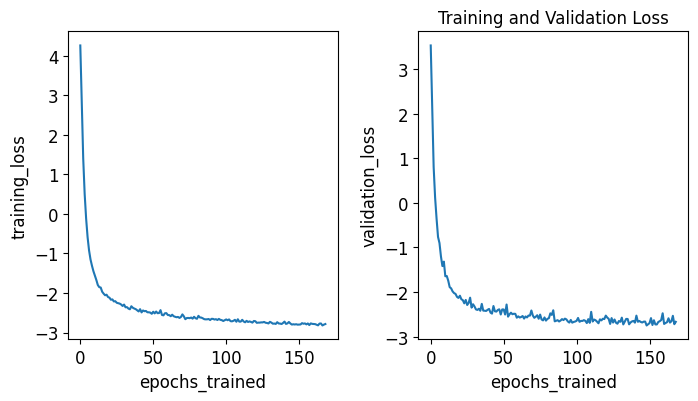

In [37]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [39]:
theta_trained = posterior.sample((num_posterior_samples,), x=x_o)
theta_trained_numpy = theta_trained.cpu().numpy()

1098it [00:00, 19921.64it/s]            


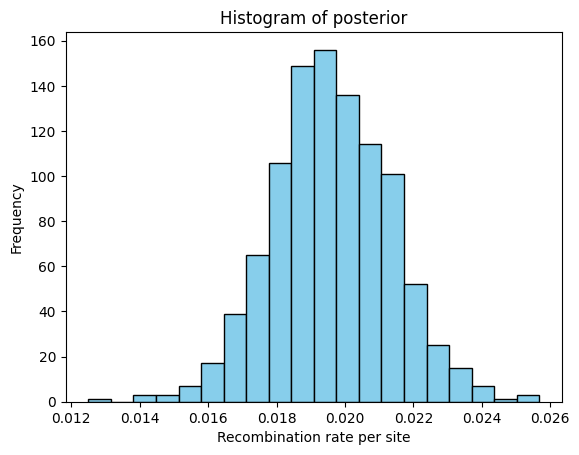

In [43]:
plt.hist(theta_trained_numpy[:, 0], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Recombination rate per site')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()

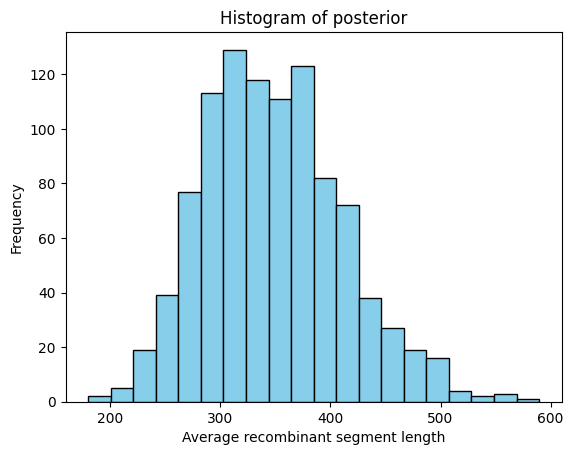

In [44]:
plt.hist(theta_trained_numpy[:, 1], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Average recombinant segment length')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()

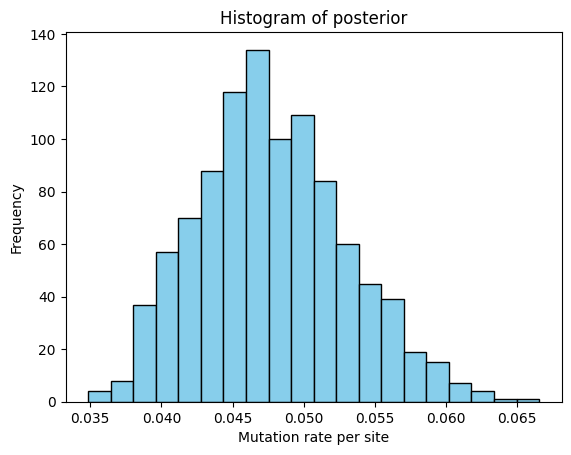

In [45]:
plt.hist(theta_trained_numpy[:, 2], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Mutation rate per site')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()

Calculating ranks for 500 SBC samples: 100%|██████████| 500/500 [00:00<00:00, 6957.04it/s]


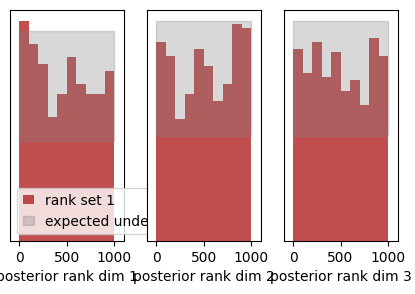

In [46]:
sbc_results = []
ranks, dap_samples = run_sbc(
    theta_sbc, 
    x_sbc, 
    posterior, 
    num_posterior_samples=1000,
    use_batched_sampling=False
)

stats = check_sbc(
    ranks, 
    theta_sbc, 
    dap_samples, 
    num_posterior_samples=1000
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats
})

fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(5, 3)
)